In [968]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 

In [969]:
df = pd.read_csv('../data/raw/housing_data.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [970]:
df.shape
df.columns
df.info()
df.describe()   
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [971]:
df.drop(['society'],axis=1,inplace=True)

In [972]:
df.dropna(subset=['location'], inplace=True)
df.dropna(subset=['size'], inplace=True)

In [973]:
df['bath'] = df['bath'].fillna(df['bath'].median())
print(df['bath'].median())
#df['bath'] = df['bath'].fillna(df['bath'].mean())
#print(df['bath'].mean())

2.0


In [974]:
df['balcony'] = df['balcony'].fillna(df['balcony'].median())
print(df['balcony'].median())

2.0


In [975]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [976]:
df.info()

<class 'pandas.DataFrame'>
Index: 13303 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13303 non-null  str    
 1   availability  13303 non-null  str    
 2   location      13303 non-null  str    
 3   size          13303 non-null  str    
 4   total_sqft    13303 non-null  str    
 5   bath          13303 non-null  float64
 6   balcony       13303 non-null  float64
 7   price         13303 non-null  float64
dtypes: float64(3), str(5)
memory usage: 1.6 MB


In [977]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [978]:
df['bhk'] = df['size'].apply(lambda x : int(x.split()[0]))
df=df.drop('size',axis=1)

In [979]:
df.head(60)

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2
5,Super built-up Area,Ready To Move,Whitefield,1170,2.0,1.0,38.00,2
6,Super built-up Area,18-May,Old Airport Road,2732,4.0,2.0,204.00,4
7,Super built-up Area,Ready To Move,Rajaji Nagar,3300,4.0,2.0,600.00,4
8,Super built-up Area,Ready To Move,Marathahalli,1310,3.0,1.0,63.25,3
9,Plot Area,Ready To Move,Gandhi Bazar,1020,6.0,2.0,370.00,6


In [980]:
df.info()

<class 'pandas.DataFrame'>
Index: 13303 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13303 non-null  str    
 1   availability  13303 non-null  str    
 2   location      13303 non-null  str    
 3   total_sqft    13303 non-null  str    
 4   bath          13303 non-null  float64
 5   balcony       13303 non-null  float64
 6   price         13303 non-null  float64
 7   bhk           13303 non-null  int64  
dtypes: float64(3), int64(1), str(4)
memory usage: 1.5 MB


In [981]:
type(df['total_sqft'])

pandas.Series

In [982]:
def convert_sqft(x):
    try:
        if '-' in x:
            a,b = x.split('-')
            return (float(a) + float(b)/2)
        return float(x)

    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

In [983]:
df.dropna(subset=['total_sqft'], inplace= True)

In [984]:
df['bhk'] = df['bhk'].astype(int)
df = df[df['total_sqft']/ df['bhk']>300]

In [985]:
df['price_per_sqft']= df['price']*100000 / df['total_sqft']

In [986]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key ,subdf in df.groupby('location'):
        m = subdf['price_per_sqft'].mean()
        st = subdf['price_per_sqft'].std()

        reduced_df = subdf[(subdf['price_per_sqft'] > (m-st)) & (subdf['price_per_sqft'] <= (m+st))]
        df_out = pd.concat([df_out,reduced_df],ignore_index=True)
    return df_out
df = remove_pps_outliers(df)

In [987]:
location_counts = df['location'].value_counts()

df['location'] = df['location'].apply(lambda x: 'other' if location_counts[x]<=10 else x)

In [988]:
df = df.drop('price_per_sqft', axis=1)

In [989]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9414 entries, 0 to 9413
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     9414 non-null   str    
 1   availability  9414 non-null   str    
 2   location      9414 non-null   str    
 3   total_sqft    9414 non-null   float64
 4   bath          9414 non-null   float64
 5   balcony       9414 non-null   float64
 6   price         9414 non-null   float64
 7   bhk           9414 non-null   int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 962.8 KB


In [990]:
df.dtypes

area_type           str
availability        str
location            str
total_sqft      float64
bath            float64
balcony         float64
price           float64
bhk               int64
dtype: object

In [991]:
df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Ready To Move,other,1100.0,2.0,1.0,70.0,2
1,Super built-up Area,Ready To Move,other,1672.0,3.0,2.0,150.0,3
2,Built-up Area,Ready To Move,other,1750.0,3.0,3.0,149.0,3
3,Super built-up Area,Ready To Move,other,1750.0,3.0,2.0,150.0,3
4,Super built-up Area,18-May,Devarachikkanahalli,1250.0,2.0,3.0,44.0,3


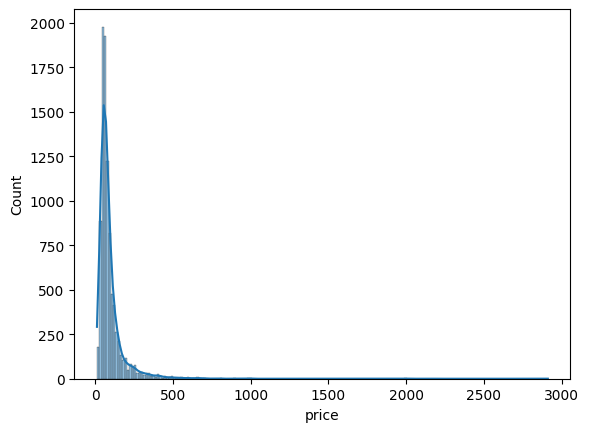

In [992]:
sns.histplot(df['price'],kde=True)
plt.show()

In [993]:
df.drop(['area_type','availability'],axis = 1)

,location,total_sqft,bath,balcony,price,bhk
0,other,1100.0,2.0,1.0,70.00,2
1,other,1672.0,3.0,2.0,150.00,3
2,other,1750.0,3.0,3.0,149.00,3
3,other,1750.0,3.0,2.0,150.00,3
4,Devarachikkanahalli,1250.0,2.0,3.0,44.00,3
...,...,...,...,...,...,...
9409,other,1780.0,3.0,1.0,84.83,3
9410,other,1322.0,2.0,1.0,61.99,2
9411,other,880.0,2.0,1.0,48.00,2
9412,other,1000.0,2.0,1.0,55.00,2


In [994]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics  import r2_score
from sklearn.metrics import confusion_matrix

In [995]:
x.columns = x.columns.str.lower()

In [1006]:
location_counts = df['location'].value_counts()
df['location'] = df['location'].apply(lambda x: x if location_counts[x]>10 else 'others')

In [1007]:
x = df.drop(['price','area_type','availability'],axis =1 )
y = np.log(df['price'])

In [1008]:
x = pd.get_dummies(x,columns=['location'])

In [1009]:
x.columns

Index(['total_sqft', 'bath', 'balcony', 'bhk', 'location_ Devarachikkanahalli',
       'location_1st Phase JP Nagar', 'location_5th Phase JP Nagar',
       'location_6th Phase JP Nagar', 'location_7th Phase JP Nagar',
       'location_8th Phase JP Nagar',
       ...
       'location_Varthur', 'location_Vidyaranyapura', 'location_Vijayanagar',
       'location_Vittasandra', 'location_Whitefield',
       'location_Yelachenahalli', 'location_Yelahanka',
       'location_Yelahanka New Town', 'location_Yeshwanthpur',
       'location_other'],
      dtype='str', length=183)

In [1010]:
x.dtypes

total_sqft                       float64
bath                             float64
balcony                          float64
bhk                                int64
location_ Devarachikkanahalli       bool
                                  ...   
location_Yelachenahalli             bool
location_Yelahanka                  bool
location_Yelahanka New Town         bool
location_Yeshwanthpur               bool
location_other                      bool
Length: 183, dtype: object

In [1011]:
print(x.columns)

Index(['total_sqft', 'bath', 'balcony', 'bhk', 'location_ Devarachikkanahalli',
       'location_1st Phase JP Nagar', 'location_5th Phase JP Nagar',
       'location_6th Phase JP Nagar', 'location_7th Phase JP Nagar',
       'location_8th Phase JP Nagar',
       ...
       'location_Varthur', 'location_Vidyaranyapura', 'location_Vijayanagar',
       'location_Vittasandra', 'location_Whitefield',
       'location_Yelachenahalli', 'location_Yelahanka',
       'location_Yelahanka New Town', 'location_Yeshwanthpur',
       'location_other'],
      dtype='str', length=183)


In [1012]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [1013]:
df.dtypes

area_type           str
availability        str
location            str
total_sqft      float64
bath            float64
balcony         float64
price           float64
bhk               int64
dtype: object

In [1016]:
model = LinearRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)


0.7488476778035109

In [1017]:
from sklearn.model_selection import cross_val_score 
scores = cross_val_score(model,x,y,cv=5)
print(scores)
print(scores.mean())

[0.62040901 0.49934484 0.59720363 0.59555879 0.70191377]
0.6028860097300905


In [1020]:
y_pred_lr = model.predict(x_test)

In [1021]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test,y_pred_lr)
rmse = mse**0.5
mae = mean_absolute_error(y_test,y_pred_lr)

print(rmse)
print(mae)

0.31243488768649075
0.2239569402366556


In [1024]:
from sklearn.ensemble import RandomForestRegressor

In [1036]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)

In [1037]:
rf_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [1038]:
rf_model.score(x_test,y_test)

0.7960705362132013

In [1039]:
y_pred_rf = rf_model.predict(x_test)

In [1040]:
mse_rf = mean_squared_error(y_test,y_pred_rf)
rmse_rf = mse_rf*0.5
mae_rf = mean_absolute_error(y_test,y_pred_rf)

print(rmse_rf)
print(mae_rf)

0.03963070784878155
0.18603002190869952


In [1041]:
from xgboost import XGBRegressor

In [1043]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [1044]:
xgb_model.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [1045]:
xgb_model.score(x_test,y_test)

0.8177839498853247

In [1049]:
y_pred_xgb = xgb_model.predict(x_test)

In [1050]:
mse_xgb = mean_squared_error(y_test,y_pred_xgb)
rmse_xgb = mse_xgb*0.5
mae_xgb = mean_absolute_error(y_test,y_pred_xgb)

print(rmse_xgb)
print(mae_xgb)

0.03541102356353624
0.19579299241969023


In [1056]:
rf_scores = cross_val_score(rf_model, x, y, cv=5)

rf_scores.mean()

np.float64(0.7472007723319275)

In [1057]:
xgb_scores = cross_val_score(xgb_model, x, y, cv=5)
xgb_scores.mean()

np.float64(0.766335696024602)

In [1060]:
feature_importance = xgb_model.feature_importances_

features = x.columns

importance_df = pd.DataFrame({
    'Feature':features,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(by='Importance',ascending=False)

importance_df.head(10)

,Feature,Importance
0,total_sqft,0.130013
150,location_Rajaji Nagar,0.023012
51,location_Chandapura,0.022684
63,location_Electronic City Phase II,0.022443
56,location_Cunningham Road,0.017877
172,location_Uttarahalli,0.017572
182,location_other,0.016797
91,location_Indira Nagar,0.015527
117,location_Koramangala,0.015449
130,location_Malleshwaram,0.014803


<function matplotlib.pyplot.show(close=None, block=None)>

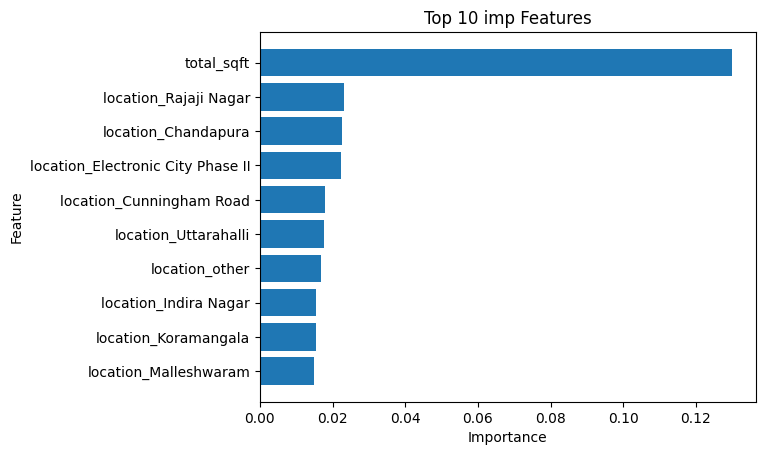

In [1063]:
top_features = importance_df.head(10)

plt.figure()
plt.barh(top_features['Feature'],top_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 imp Features')
plt.gca().invert_yaxis()
plt.show

In [1065]:
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor()

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[3,5,7],
    'learning_rate':[0.05,0.1]
}


grid = GridSearchCV(xgb, param_grid,cv=3, scoring='r2',verbose=1)

grid.fit(x_train,y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [1070]:
grid.best_params_
grid.best_score_

np.float64(0.8513747841442374)

In [1071]:
best_model = grid.best_estimator_

best_model.score(x_test,y_test)

0.8326854407128383

In [1073]:
import joblib
joblib.dump(best_model,'../models/house_price_model.joblib')

['../models/house_price_model.joblib']

In [1077]:
import json
with open('../models/columns.json','w') as f:
    json.dump(list(x.columns),f)


In [1078]:
with open('../models/columns.json','r') as f:
    columns = json.load(f)
print(columns[:10])

['total_sqft', 'bath', 'balcony', 'bhk', 'location_ Devarachikkanahalli', 'location_1st Phase JP Nagar', 'location_5th Phase JP Nagar', 'location_6th Phase JP Nagar', 'location_7th Phase JP Nagar', 'location_8th Phase JP Nagar']


In [1079]:
df.head(
)

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Ready To Move,other,1100.0,2.0,1.0,70.0,2
1,Super built-up Area,Ready To Move,other,1672.0,3.0,2.0,150.0,3
2,Built-up Area,Ready To Move,other,1750.0,3.0,3.0,149.0,3
3,Super built-up Area,Ready To Move,other,1750.0,3.0,2.0,150.0,3
4,Super built-up Area,18-May,Devarachikkanahalli,1250.0,2.0,3.0,44.0,3


In [1080]:
x.head()

,total_sqft,bath,balcony,bhk,location_ Devarachikkanahalli,location_1st Phase JP Nagar,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,...,location_Varthur,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yeshwanthpur,location_other
0,1100.0,2.0,1.0,2,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1672.0,3.0,2.0,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1750.0,3.0,3.0,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1750.0,3.0,2.0,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1250.0,2.0,3.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [1081]:
y.head()

0    4.248495
1    5.010635
2    5.003946
3    5.010635
4    3.784190
Name: price, dtype: float64

In [1082]:
x.to_csv('../data/processed/x_processed.csv',index=False)
y.to_csv('../data/processed/y_processed.csv',index=False)

In [1086]:
from src.predict import predict_price
predict_price(1200,2,1,2,'Whitefield')

ModuleNotFoundError: No module named 'src'

In [1088]:
print(best_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)
